 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Jamie Buckett               <br>
Student Number : L00196573         <br>
Due Date       : 12th may 2026                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## Datasets 

The RVL-CDIP Dataset test - https://www.kaggle.com/datasets/pdavpoojan/the-rvlcdip-dataset-test

OCR Receipts Text Detection retail dataset - https://www.kaggle.com/datasets/trainingdatapro/ocr-receipts-text-detection

Aniaml Image Dataset - https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals

Microsoft Responsible AI Transparency Report 2025 - https://www.microsoft.com/en-us/corporate-responsibility/responsible-ai-transparency-report/

Anthropic Labour market impacts of AI: A new measure and early evidence - https://cdn.sanity.io/files/4zrzovbb/website/2b5bbaf2c1eb81dbf6e6fb813c1a24e35a64d376.pdf

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs

Perform imports

## Install packages

In [9]:
# install required packages
%pip install opencv-python pytesseract numpy pandas matplotlib scikit-learn spacy nltk pdf2image pillow easyocr ipykernel pymupdf 


Note: you may need to restart the kernel to use updated packages.


In [10]:
# download the spacy english model
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 4.8 MB/s eta 0:00:03
     ----------------- ---------------------- 5.5/12.8 MB 9.9 MB/s eta 0:00:01
     ------------------------------ -------- 10.0/12.8 MB 13.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 13.4 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Imports

In [11]:
# importing required libraries
import re as regex
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pytesseract
import spacy
import string
import nltk
from sympy import re
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, RegexpStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer # <--- Add this import
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from pdf2image import convert_from_path
from IPython.display import Image, display
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon') 

# load english nlp model
nlp = spacy.load("en_core_web_sm")

# path to tesseract
pytesseract.pytesseract.tesseract_cmd = pytesseract.pytesseract.tesseract_cmd = r'C:\Users\jamie\OneDrive\Data Analytics and AI\AI for Vision and NLP\Tesseract\tesseract.exe'

# path to poppler
poppler = r"C:\Users\jamie\OneDrive\Data Analytics and AI\AI for Vision and NLP\Poppler\poppler-25.12.0\Library\bin"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jamie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jamie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jamie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jamie\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jamie\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# NLP Support Functions

## OCR Text Extraction Function

Source for OCR text extraction - https://www.geeksforgeeks.org/python/text-detection-and-extraction-using-opencv-and-ocr/  

Source for thresholding -  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

Source for filtering - https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html

In [12]:
# function to extract text from an image
def get_text(img_path):
    # read the image
    img = cv2.imread(img_path)
    
    # convert the image to grayscale to remove colour noise
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # apply a gaussian blur to the image to further reduce noise, smooth the image
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # apply adaptive thresholding to handle uneven lighting and shadows
    binary = cv2.adaptiveThreshold(
        blurred, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11,  2
    )  
        
    # extract text from the image using pytesseract
    extracted_text = pytesseract.image_to_string(binary)
    
    # return the extracted text
    return extracted_text

### Example of OCR Text Extraction Function

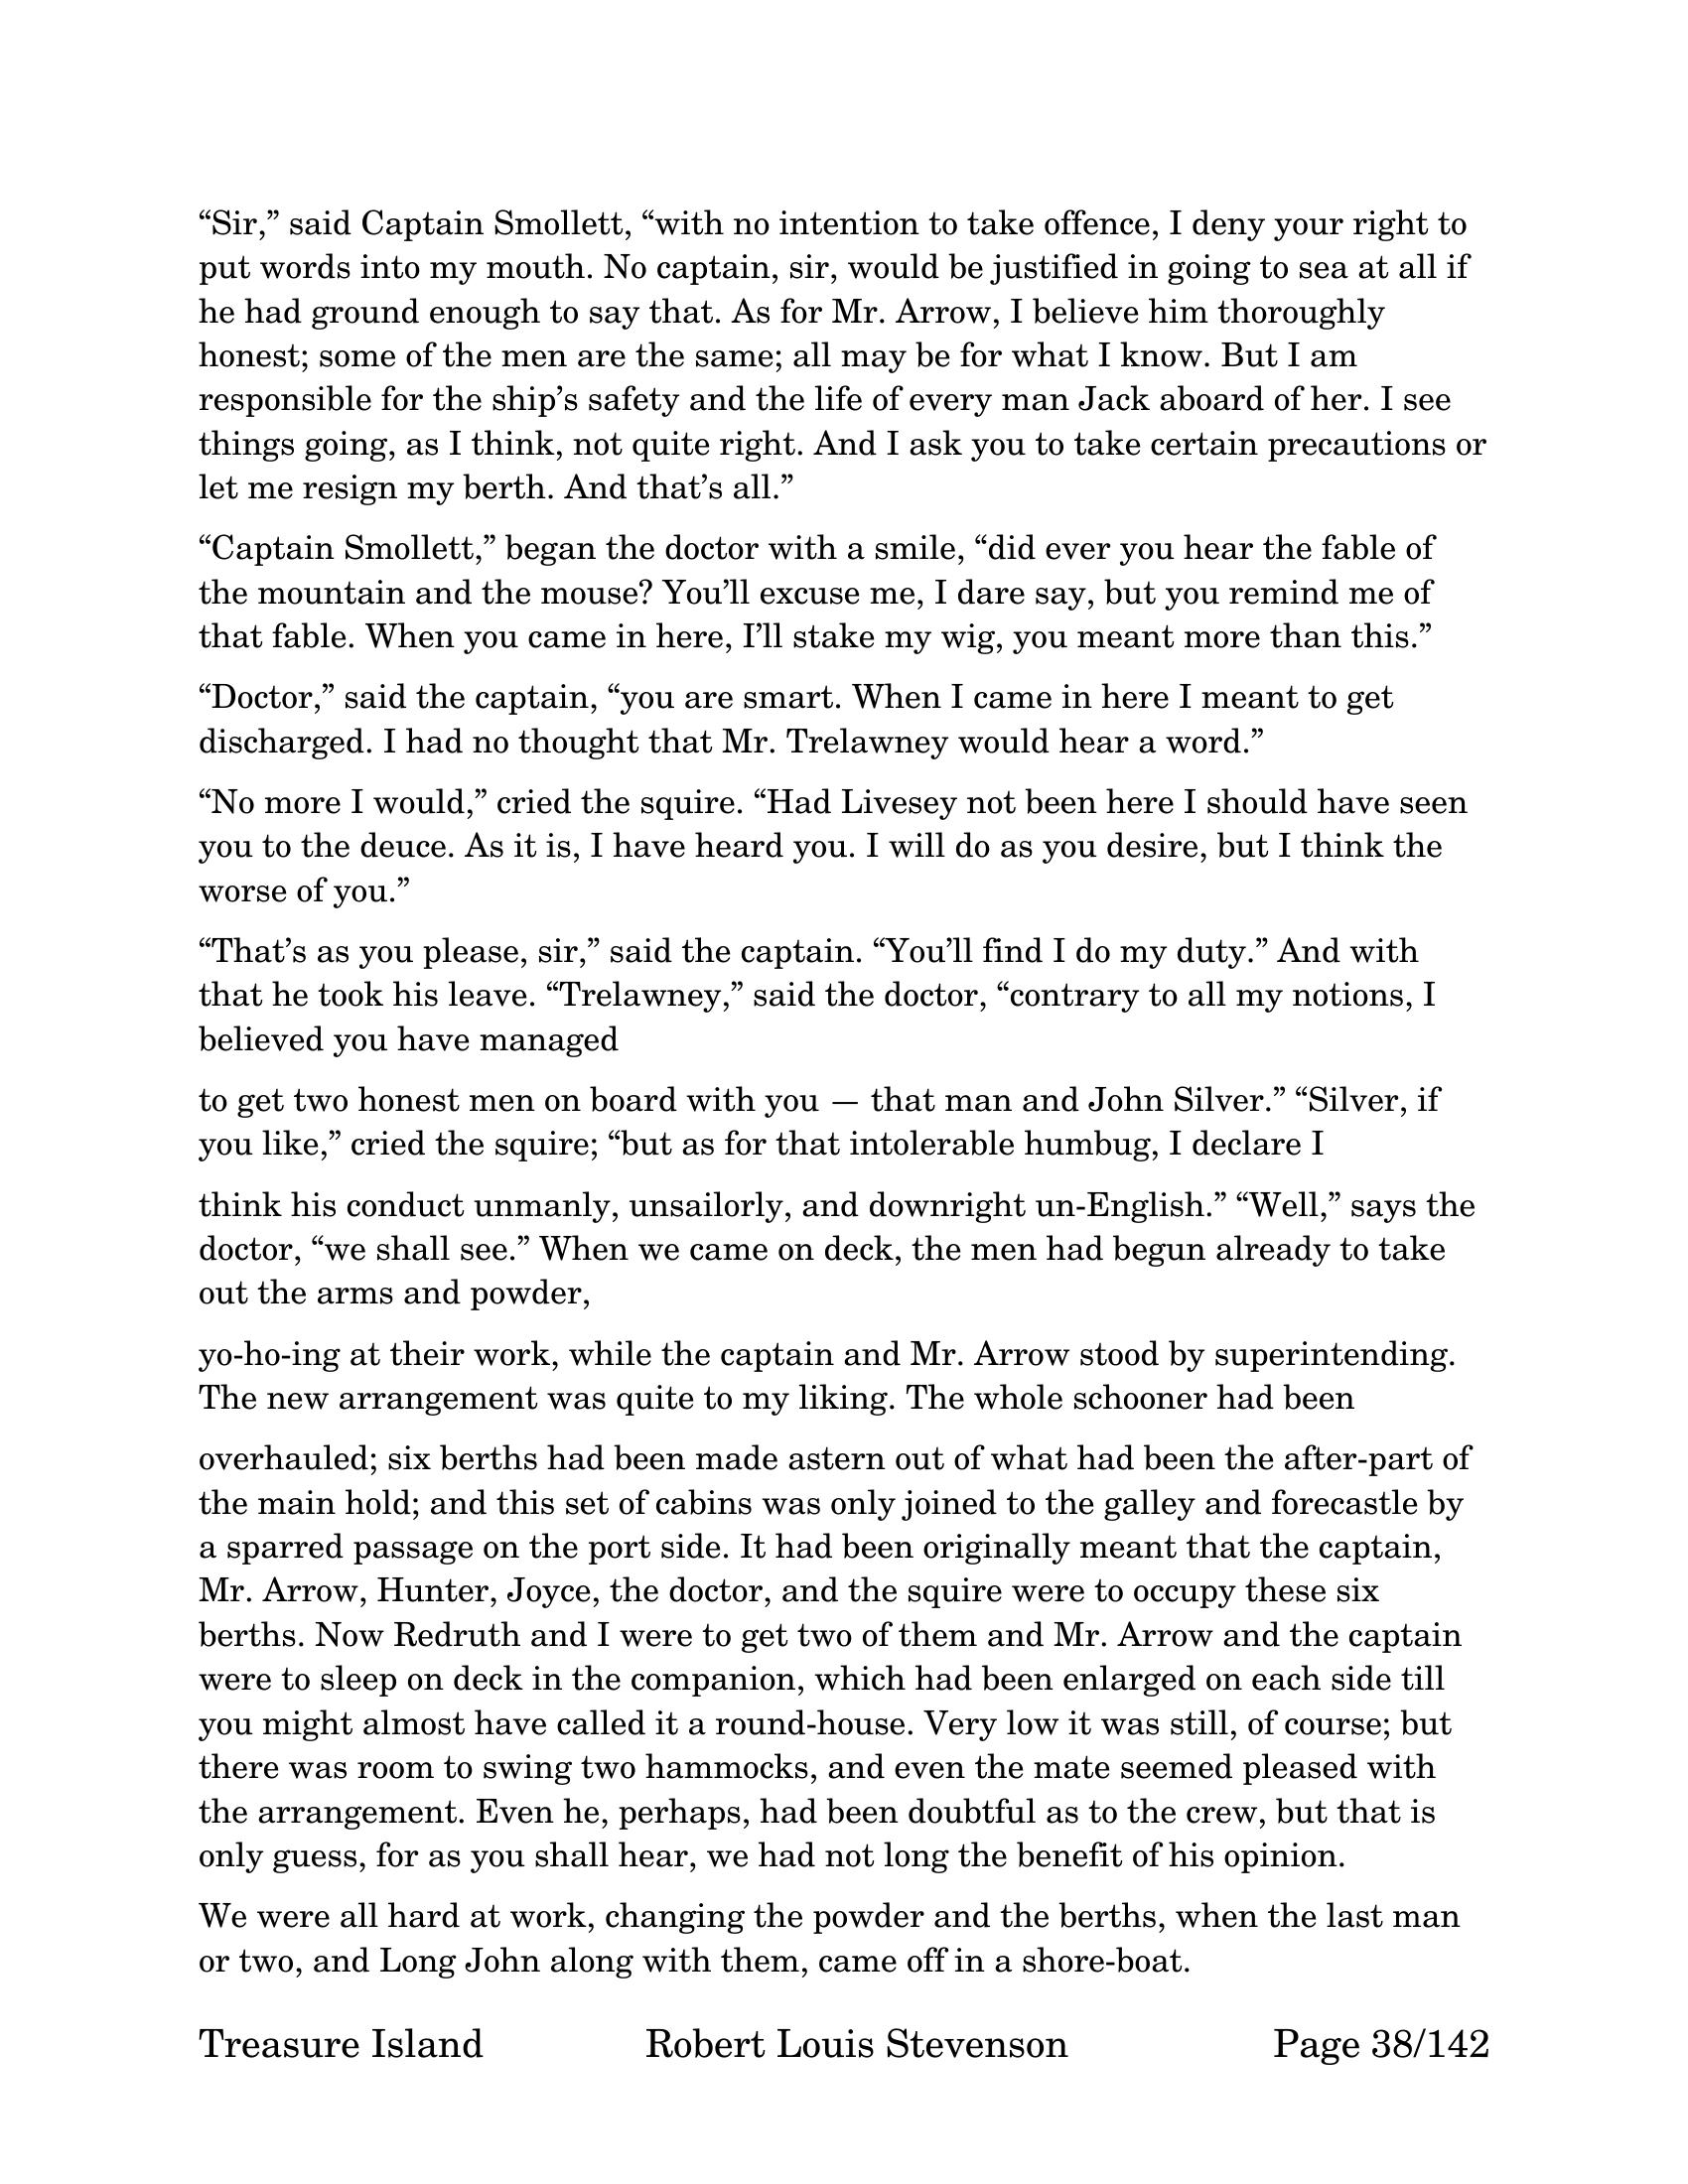

“Sir,” said Captain Smollett, “with no intention to take offence, I deny your right to
put-words.into my mouth. No captain, sir, would be justified in going to sea at all if’
he'had ground enough to say that. As for.Mr..Arrow, I believe him thoroughly
honest; some of the men‘are the same; all: may be for what I know: But I am
responsible for the ship’s safety and the life of every man'Jack aboard of her..I'see
things going, as I think, not quite right. And Task you to take certain precautions or
let me resign my berth. And that’s all.”

“Captain Smollett,” began the doctor with a smile, “did-ever you hear the fable of
the mountain andthe mouse? You'll. excuse me,.I'dare say, but you remind:me of
that fable. When you came in here, I'll stake my wig, you: meant more than this.”

“Doctor;” said the captain,.“you are smart. When I came‘in here I meant‘to get:
discharged. I had:no thought that Mr. Trelawney would hear‘a word.”

“No more I would;” cried the'squire. “Had Livesey not been here

In [ ]:
# demo file to test the function on
demo_file = "Teasure_Island_pg38.jpg" 

# show the demo file
display(Image(filename=demo_file, width=500))

# run the extraction
extracted_demo_text = get_text(demo_file)

# print a sample of the extracted text
print(extracted_demo_text[:1000])

## PDF to Image Function

Source for pdf to image - https://www.geeksforgeeks.org/python/convert-pdf-to-image-using-python/

Source for Poppler - https://github.com/oschwartz10612/poppler-windows/releases/tag/v25.12.0-0 

In [13]:
# function to convert pdf to images for OCR
def pdf_to_image(pdf_path):
           
    # convert pdf to images using poppler
    pages = convert_from_path(pdf_path, poppler_path=poppler)
    
    # save the images to disk and store their paths in a list
    image_paths = []
    # loop through the pages and save them as images
    for i, page in enumerate(pages):
        # create a name for each image based on the page number
        img_name = f"converted_page_{i+1}.jpg"
        # save the image to disk
        page.save(img_name, "JPEG")
        # add the image path to the list
        image_paths.append(img_name)
    
    # print the number of images created    
    print(f"created {len(image_paths)} image(s).")
    # return the list of image paths
    return image_paths

### Example of the PDF Image Function

In [3]:
# demo file to test the function on
demo_file = "TreasureIsland_pg89.pdf"

# run the conversion
demo_images = pdf_to_image(demo_file)
# grab the first image to show and run OCR on
demo_target = demo_images[0]

# show the image that will be used for OCR
display(Image(filename=demo_target, width=500)) 

# run the extraction
extracted_demo_text = get_text(demo_target)

# show a sample of the extracted text
print(extracted_demo_text[:1000])

NameError: name 'convert_from_path' is not defined

## Text Preprocessing Function

source for text preprocessing - https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/

source for lemmatisation - https://spacy.io/api/lemmatizer and https://www.nltk.org/book/ch03.html 

In [14]:
# function to preprocess text using spacy and apply lemmatisation
def preprocess_text(raw_text):
    
    # create a spacy doc object from the text
    doc = nlp(raw_text)
    
    # use spacys lemmatisation to get the base of each word, remove stop words and punctuation
    lemmatised_text = [
        # convert the lemmatised token to lowercase and add it to the list
        token.lemma_.lower()
        # only include tokens that are not stop words, punctuation, or whitespace
        for token in doc 
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    # return the preprocessed text as a string
    return " ".join(lemmatised_text)

### Example of Text Preprocessing Function

In [62]:
# load text file for demo 
with open('Treasure_Island.txt', 'r', encoding='utf-8') as f:
    file_text = f.read()

# show a sample of the original text
print(f"Original Text (sample)")
print(file_text[:144])
print("\n")

# run the preprocessing function
preprocessed_file_text = preprocess_text(file_text)

# show a sample of the preprocessed text
print(f"Preprocessed Text (sample)")
print(preprocessed_file_text[:144])

Original Text (sample)
You may fancy the terror I was in! I should have leaped out and run for it if I had
found the strength, but my limbs and heart alike misgave me.


Preprocessed Text (sample)
fancy terror leap run find strength limb heart alike misgave hear dick begin rise seemingly stop voice hands exclaim oh stow sucking bilge john 


## Text Feature Extraction

Source for text extraction - https://www.geeksforgeeks.org/nlp/feature-extraction-techniques-nlp/

Source for sentiment analyser - https://www.nltk.org/api/nltk.sentiment.SentimentIntensityAnalyzer.html?highlight=sentimentintensity




In [15]:
# function to extract features from the text using spacy
def text_feature_extraction(raw_text, cleaned_text):
    # create a dictionary to store the features
    features = {}
    
    # create a spacy doc object from the text
    doc = nlp(raw_text)
    
# create a dictionary to store the named entities
    entities = {}
    # loop through the named entities in the doc and add them to the dictionary
    for ent in doc.ents:
        # if the entity label is not already in the dictionary add it with an empty set
        if ent.label_ not in entities:
            entities[ent.label_] = set()
        # add the entity text to the set for the label 
        entities[ent.label_].add(ent.text)
     
# convert the sets of entities to lists and add them to the features dictionary   
    features['Named_Entities'] = {k: list(v) for k, v in entities.items()}
    
# use nltk to tokenise the cleaned text into sentences for TF-IDF
    sentences = sent_tokenize(cleaned_text)
    
# use tf-idf to extract keywords and add them to the feature dictionary
    if len(sentences) > 1:
        vectorizer = TfidfVectorizer(max_features=10)
        vectorizer.fit_transform(sentences)
        features['Keywords'] = list(vectorizer.get_feature_names_out())
    else:
        features['Keywords'] = cleaned_text.split()[:10]
    
    # use nltk to get the sentiment of the text and add it to the features dictionary    
    sia = SentimentIntensityAnalyzer()
    # get the compound sentiment score and add it to the features dictionary
    compound = sia.polarity_scores(raw_text)['compound']
    
    # find the sentiment label based on the compound score and add it to the features dictionary
    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
# add the sentiment score and label to the features dictionary    
    features['Sentiment'] = {
        'Score': compound,
        'Label': sentiment
    }
    
    # return the features dictionary
    return features

### Example of Text Feature Extraction Function

In [67]:
# load text file for demo
with open('Treasure_Island.txt', 'r', encoding='utf-8') as f:
    file_text = f.read()

# get preprocessed text
preprocessed_text = preprocess_text(file_text)

# run the feature extraction
features = text_feature_extraction(file_text, preprocessed_text)

# show sentiment 
print(f"Sentiment: {features['Sentiment']['Label']} (Score: {features['Sentiment']['Score']:.2f})")

# show the keywords
print(f"Keywords: {', '.join(features['Keywords'])}")

# show the named entities
print("\nNamed Entities:")
for category, names in features['Named_Entities'].items():
    print(f"  - {category}: {', '.join(names)}")

Sentiment: Negative (Score: -0.90)
Keywords: fancy, terror, leap, run, find, strength, limb, heart, alike, misgave

Named Entities:
  - PERSON: John, Dick, Dr. Livesey, Arrow, Hunter, Smollett, Silver
  - GPE: Flint, Israel
  - CARDINAL: two, three, one, them’ll
  - ORG: Chapter XII - Council of War, HISPANIOLA
  - ORDINAL: third


### Text Analysis Structure Function

source for document layout analysis - https://github.com/UglyToad/PdfPig/wiki/Document-Layout-Analysis

In [16]:
def analyse_text_structure(raw_text):
    
    # create a spacy doc object from the text
    doc = nlp(raw_text)
    
    # create a dictionary to store the analysis results
    analysis = {
        "titles": [],
        "body": [],
        "captions": [], 
        "tabular_data": [] 
    }
    
    # regex for captions and image references
    ref_pattern = regex.compile(r"(?i)(figure|fig\.|table|diagram|chart)\s*\d*")
    # regex for table rows 
    table_pattern = regex.compile(r'\s{4,}|\t|\|')
    
    # extract tabular data by checking physical line breaks
    for line in raw_text.split('\n'):
        # strip the whitespace from the line
        clean_line = line.strip()
        # if the line matches the table pattern and has more than one word then add it to the tabular data list
        if table_pattern.search(clean_line) and len(clean_line.split()) > 1:
            # add the clean line to the tabular data list in the analysis dictionary
            analysis["tabular_data"].append(clean_line)
            
    # extract titles, body, and captions
    for sent in doc.sents:
        # strip the whitespace from the sentence
        text = sent.text.strip()
        # if the sentence is empty then skip it
        if not text:
            continue
        
        # split titles and body text based on length and capital letters
        if len(text.split()) <= 8 and text.istitle():
            # add the clean line to the titles list
            analysis["titles"].append(text)
        else:
            # stop double counting: only add to body if it fails the table regex
            if not table_pattern.search(text):
                analysis["body"].append(text)
            
        # extract captions and visual references
        found_refs = ref_pattern.findall(text)
        if found_refs:
            analysis["captions"].append({
                "type": found_refs,
                "sentence": text
            })
            
    return analysis

### Example of Analysis Structure Function 

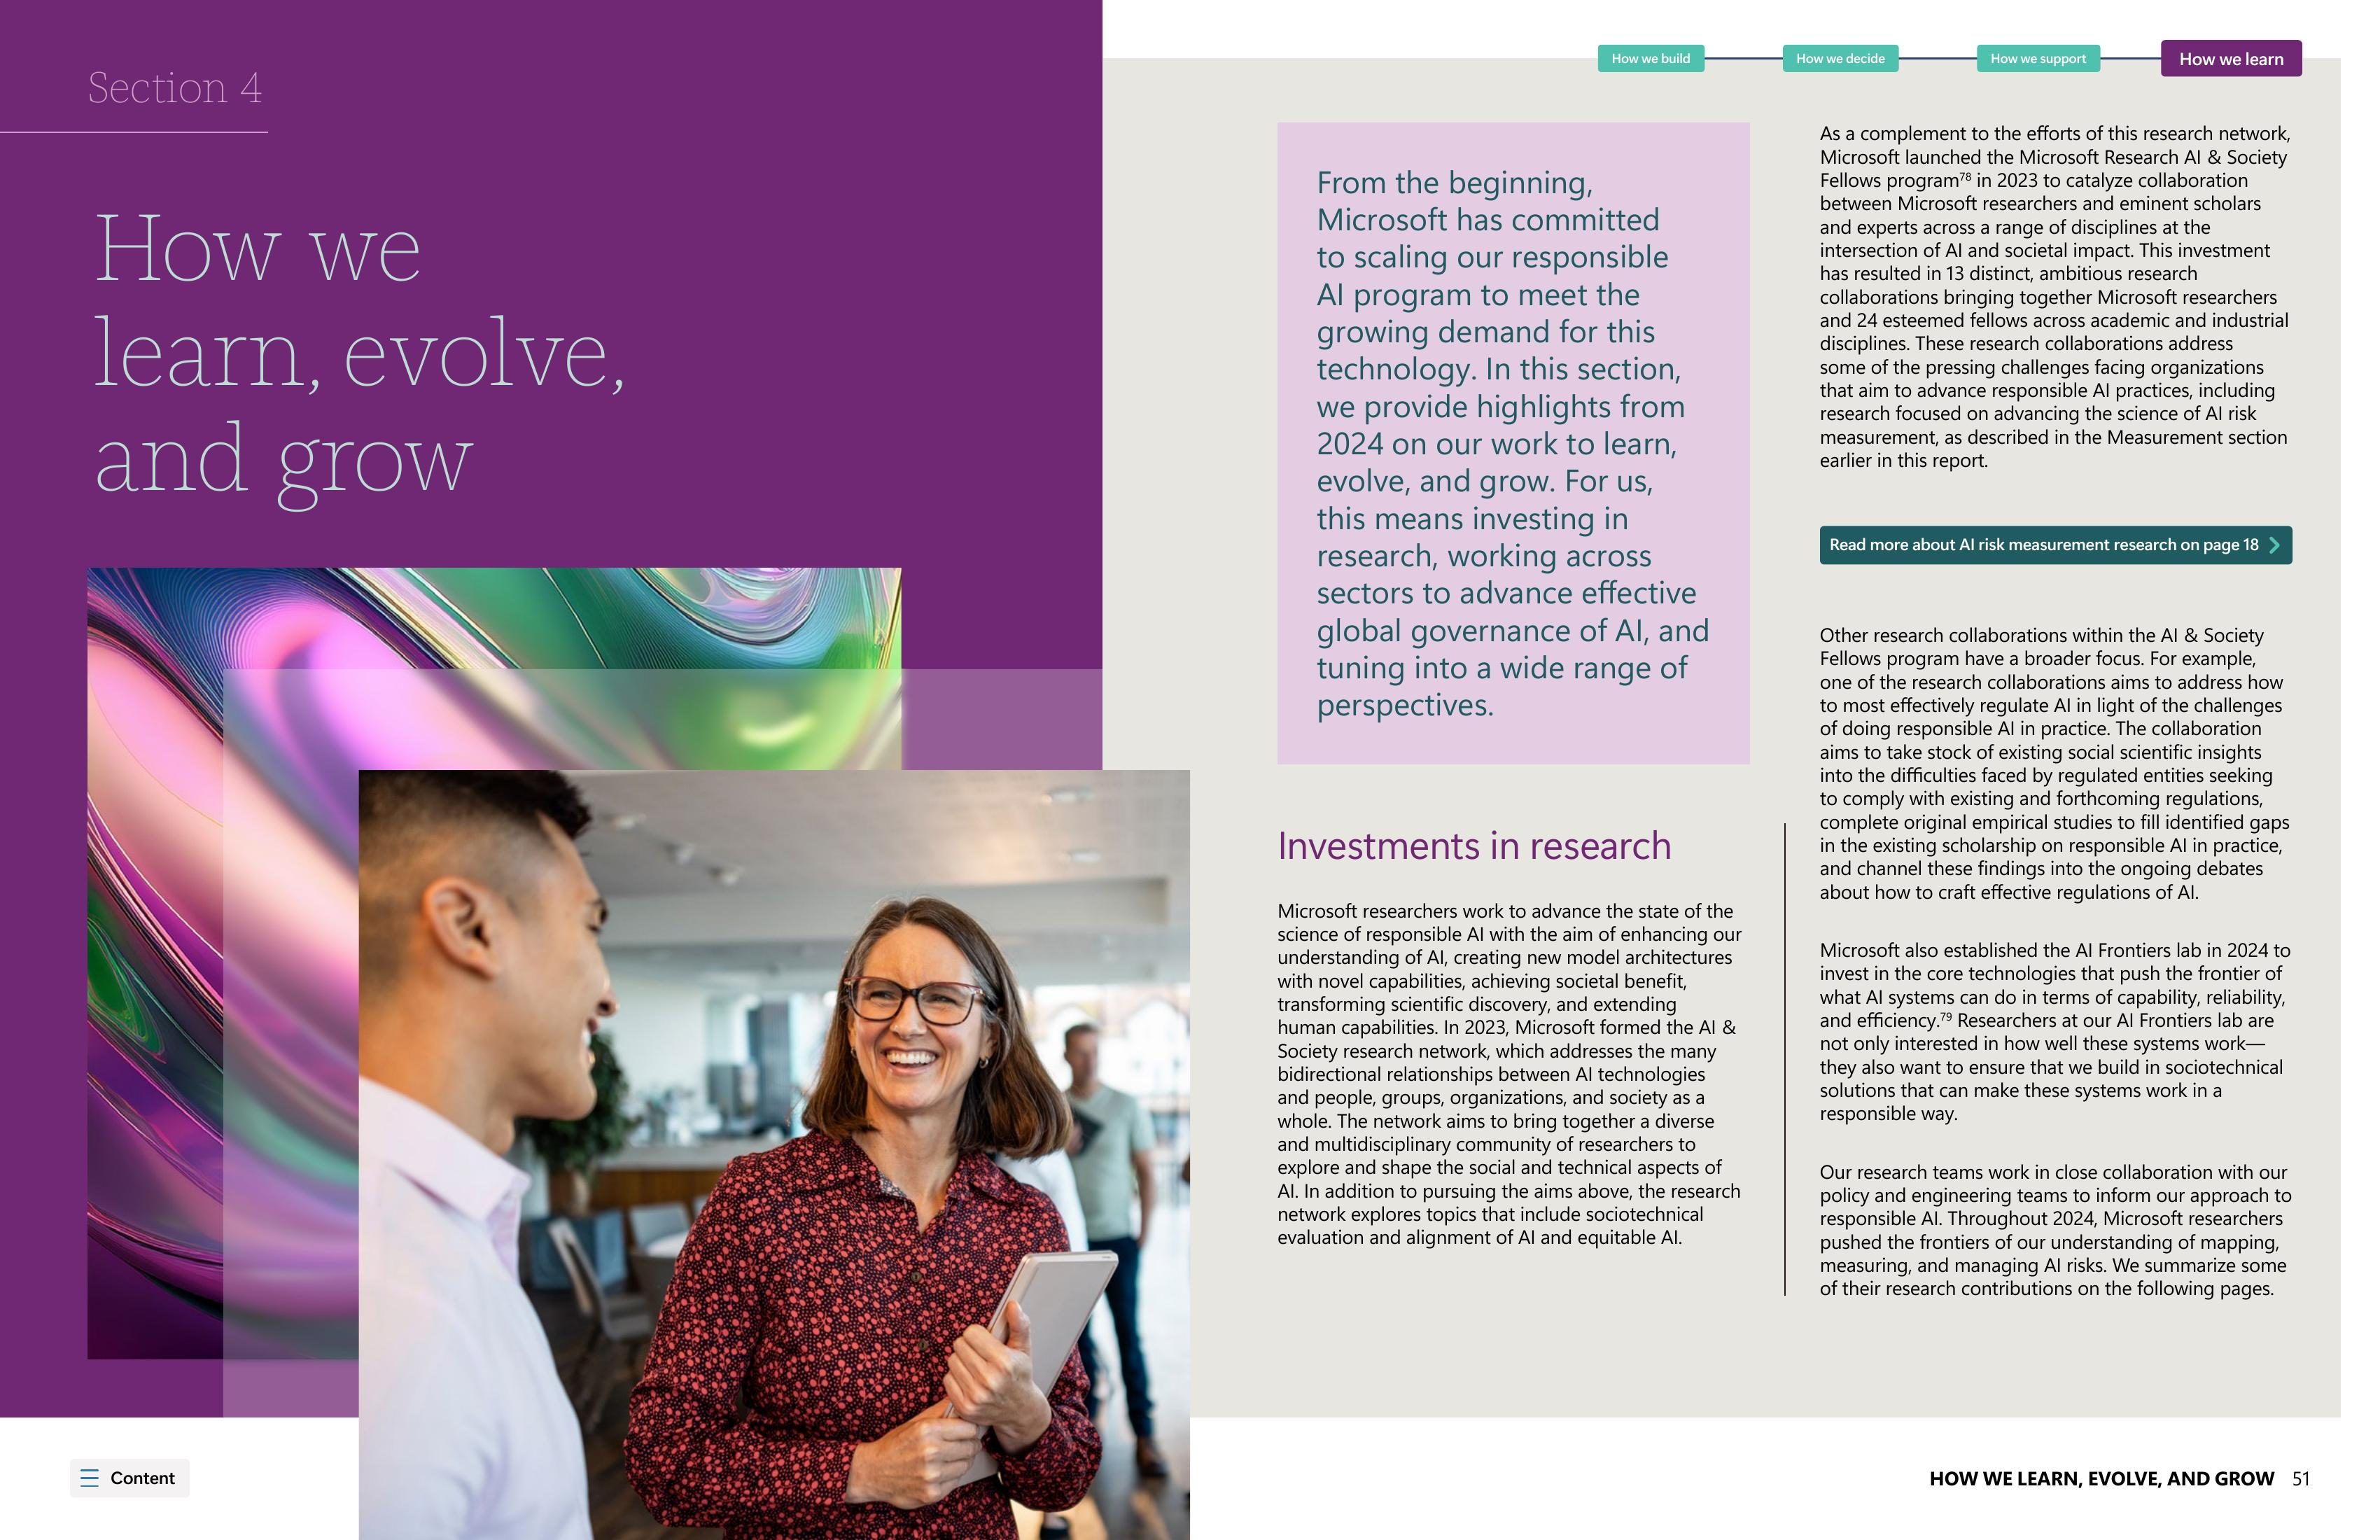

Titles found: []
Tables found: 0
Body text: 27
Caption found: and equitable Al.:

As a‘complement-to the efforts of this research network,
Microsoft launched the Microsoft Research Al & Society
Fellows program’?


In [ ]:
# demo file to test the function on
demo_image = "AI_Report_pg27.jpg" 

# show the demo image
display(Image(filename=demo_image, width=500))

# get the text from the image
raw_text = get_text(demo_image)

# run the text structure analysis
structure = analyse_text_structure(raw_text)

# print the results
print(f"Titles found: {structure['titles']}")
print(f"Tables found: {len(structure['tabular_data'])}")
print(f"Body text: {len(structure['body'])}")
print(f"Caption found: {structure['captions'][0]['sentence']}")

# NLP

Source for NLP pipeline - https://spacy.io/usage/processing-pipelines

## NLP pipeline

Function to run the NLP pipeline

In [7]:
# function to run the full nlp pipeline 
def run_nlp_pipeline(file_path):
    
    # OCR extraction 
    raw_text = get_text(file_path)

    # preprocessing 
    cleaned_text = preprocess_text(raw_text)
    
    # feature extraction
    features = text_feature_extraction(raw_text, cleaned_text)
    
    # text analysis
    structure = analyse_text_structure(raw_text)
    
    # put the results into a dictionary and return it
    return {
        "file": file_path,
        "raw_text": raw_text,
        "cleaned_text": cleaned_text,
        "features": features,
        "structure": structure
    }

## Cell to run one pdf file through the NLP pipeline

In [20]:
# add the name of the file to process
target_file = 'Anthropic_Report.pdf' 

# check the extension to convert pdfs to images for OCR
_, ext = os.path.splitext(target_file)

# convert pdfs to images if neededor just use the image file directly
if ext.lower() == '.pdf':
    images = pdf_to_image(target_file)
else:
    images = [target_file]

# process all pages and store the data
all_results = []

# loop through the images, run the nlp pipeline on each one and store the results in a list
for img in images:
    result = run_nlp_pipeline(img)
    if result:
        all_results.append(result)

print(f"\n processed {len(all_results)} page(s).")

# check the results and print a preview of the first page
if all_results:
    page_1 = all_results[0]
    print("\nPreview of Page 1")
    print(f"Sentiment: {page_1['features']['Sentiment']['Label']} ({page_1['features']['Sentiment']['Score']})")
    print(f"Keywords: {', '.join(page_1['features']['Keywords'][:5])}")
    print(f"Titles: {len(page_1['structure']['titles'])}")
    print(f"Captions: {len(page_1['structure']['captions'])}")

created 17 image(s).


KeyboardInterrupt: 

## Cell to process extract text from a diverse set of document images (e.g., scanned documents, photos of printed forms, PDFs, etc.)"

Sources for batch processing - https://realpython.com/python-list/ and https://python-batch-runner.readthedocs.io/en/latest/example/


In [ ]:
# list the documents to process through the nlp pipeline
documents = [
    "AI_Report_2025.pdf",
    "budget_scan.tif",      
    "advert_scan.tif",
    "Mythos_scan.pdf",
    "handwritten_scan.tif",
    "news_article_scan.tif"
]

# list to hold the data for all documents
master_dataset = []

# loop through the documents and process them through the pipeline
for target_file in documents:
    print(f"\nstarting: {target_file}")
    
    # send the pdfs to the converter
    _, ext = os.path.splitext(target_file)
    if ext.lower() == '.pdf':
        images = pdf_to_image(target_file)
    # if it's not a pdf then use the image file
    else:
        images = [target_file]
        
    # run the pipeline on the images/pages
    for img in images:
        result = run_nlp_pipeline(img)
        if result:
            master_dataset.append(result)

            print(f"Sentiment:{result['features']['Sentiment']['Label']} ({result['features']['Sentiment']['Score']:.2f})")
            print(f"Keywords: {', '.join(result['features']['Keywords'][:5])}")
            print(f"Captions: {len(result['structure']['captions'])}")
            print(f"Tables: {len(result['structure']['tabular_data'])}")
            print("-" * 50)

print(f"\n processed {len(master_dataset)} page(s)")


starting: AI_Report_2025.pdf
created 35 image(s).
Sentiment:Positive (0.61)
Keywords: ata, microsoft, 2025, responsible, al
Captions: 0
Tables: 3
--------------------------------------------------
Sentiment:Positive (0.93)
Keywords: content, foreword, key, takeaway, build
Captions: 0
Tables: 0
--------------------------------------------------
Sentiment:Positive (1.00)
Keywords: foreword, =, content, 2024, release
Captions: 0
Tables: 0
--------------------------------------------------
Sentiment:Positive (1.00)
Keywords: 2024, key, investment, responsible, al
Captions: 1
Tables: 1
--------------------------------------------------
Sentiment:Positive (0.83)
Keywords: towne, turd, hon, wed, ronnie
Captions: 0
Tables: 1
--------------------------------------------------
Sentiment:Positive (1.00)
Keywords: govern, policy, practice, process, responsible
Captions: 0
Tables: 0
--------------------------------------------------
Sentiment:Positive (1.00)
Keywords: eu, al, act, implementation, 

# Vision Support Functions

## Image Preprocessing Function

source for openCV grayscale - https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html

source for image thresholding - https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

Source for gaussian blur - https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html


In [4]:
# function to extract text from an image
def preprocess_image(image_path):
    # read the image
    img = cv2.imread(image_path)
    
    # convert the image to grayscale to remove colour noise
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # apply a gaussian blur to the image to further reduce noise, smooth the image
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # apply adaptive thresholding to handle uneven lighting and shadows
    binary = cv2.adaptiveThreshold(
        blurred, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11,  2
    )  
        
    # return the preprocessed image
    return binary

### Example of Image Preprocessing Function

source for displaying images matlib - https://www.geeksforgeeks.org/python/how-to-display-multiple-images-in-one-figure-correctly-in-matplotlib/

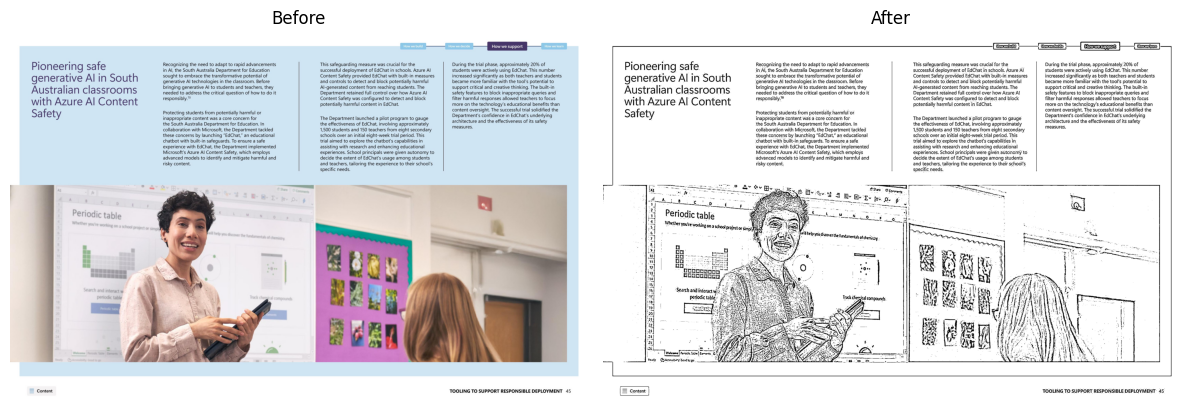

In [14]:
# demo file to test the function on
demo_file = "AI_Report_pg24.jpg" 

# load original
original = cv2.imread(demo_file)
# convert original to rgb for displaying with matplotlib
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# run the preprocessing function
processed = preprocess_image(demo_file)

# show them side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# original image
ax[0].imshow(original_rgb)
# set title and hide axes
ax[0].set_title("Before")
ax[0].axis('off')

# processed image
ax[1].imshow(processed, cmap='gray')
# set title and hide axes
ax[1].set_title("After")
ax[1].axis('off')

# adjust layout and show the images
plt.tight_layout()
plt.show()

## Feature Detection Function

source for edge, contour, corner - https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html
https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html 

source for ORB - https://docs.opencv.org/4.x/d1/d89/tutorial_py_orb.html
https://docs.opencv.org/4.x/da/d44/classcv_1_1cuda_1_1ORB.html

source for structuring element https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html#autotoc_md1455

In [ ]:
# function to detect features in a document
def detect_features(image_path):
    
    # load the image and make a grayscale version for processing
    img = cv2.imread(image_path)
    output = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # blur the image to reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # find the edges (sharp changes in color)
    edges = cv2.Canny(blur, 50, 150)
    
    # morphological dilation
    # smudge the white pixels words together 
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 5))
    # dilating the image to smudge the edges together so lines of text turn into solid blocks
    dilated = cv2.dilate(edges, kernel, iterations=3)
    
    # find the outlines of the smudged blocks
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # draw boxes around the big blocks of text and count them
    blocks = 0
    for c in contours:
        # only keep the big blocks ignore small bits of noise
        if cv2.contourArea(c) > 1000:
            x, y, w, h = cv2.boundingRect(c)
            # draw a green box around the text/layout blocks
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
            blocks += 1

    # ORB finds interesting points like corners or textures so good for photos/graphs
    orb = cv2.ORB_create(nfeatures=500)
    keypoints, des = orb.detectAndCompute(gray, None)
    
    # draw red circles over the visual features
    output = cv2.drawKeypoints(output, keypoints, None, color=(0, 0, 255), 
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        
    return output

### Example of Feature Dectection Function

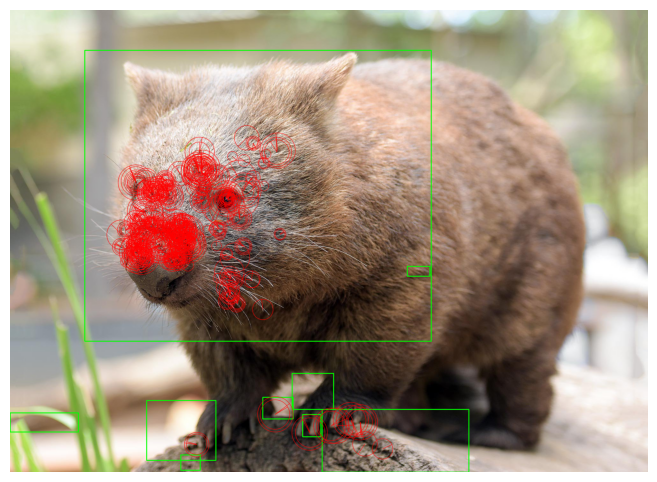

In [12]:
# demo file to test the function on
demo_image = "wombat.jpg" 

# run the detection function
# this returns the image with the boxes and circles drawn on it
detected_image = detect_features(demo_image)

# show the result
plt.figure(figsize=(12, 6))
# convert from bgr to rgb so the colors look right
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
# hide the axes
plt.axis('off')
plt.show()

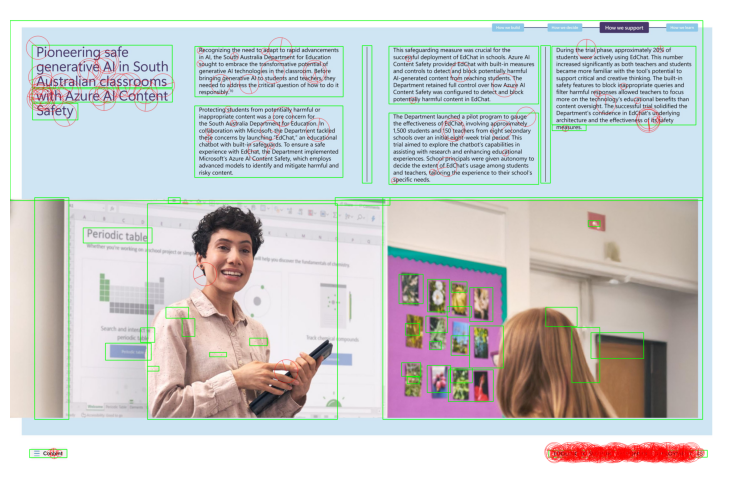

In [13]:
# demo file to test the function on
demo_image = "AI_Report_pg24.jpg" 

# run the detection function
# this returns the image with the boxes and circles drawn on it
detected_image = detect_features(demo_image)

# show the result
plt.figure(figsize=(12, 6))
# convert from bgr to rgb so the colors look right
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
# hide the axes
plt.axis('off')
plt.show()

## Image Segmentation Function

source for connected component and analysis - https://www.geeksforgeeks.org/machine-learning/python-opencv-connected-component-labeling-and-analysis/ 

Source for connected components with stats - https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f



In [22]:
# function to segment the image into text and visuals using connected components (geeks for geeks was a big help for this)
def image_segmentation(image_path):
    # load the image and make a grayscale version
    image = cv2.imread(image_path)
    out = image.copy()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # binary thresholding
    # invert the colours because connected components looks for white pixels 
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # morphological dilation
    # smudge the white pixels words together 
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 5))
    # dilating the image to bridge the gaps between letters and words to form solid blocks for connected components to find
    dilated = cv2.dilate(binary, kernel, iterations=2)
    
    # connected components analysis
    # find connected components in the dilated image which should be blocks of text or visuals
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(dilated, connectivity=4, ltype=cv2.CV_32S)
    
    # counters for the number of text blocks and visual blocks found
    texts = 0
    visuals = 0
    
    # loop through the blocks
    for i in range(1, num_labels):
        
        # pulling out the coordinates just like the geek for geeks tutorial
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        
        # ignore tiny dust spots
        if area > 500:
            
            # use aspect ratio to guess if it's text or a picture
            aspect_ratio = w / float(h)
            
            # if it is wide and short it is probably a line of text
            if aspect_ratio > 3.0 or h < 50:
                # draw a blue box around the text blocks
                cv2.rectangle(out, (x, y), (x + w, y + h), (255, 0, 0), 2)
                texts += 1
                
            # otherwise it is a big block and probably a picture or table
            else:
                # draw an orange box around the visual blocks
                cv2.rectangle(out, (x, y), (x + w, y + h), (0, 165, 255), 3)
                visuals += 1
                 
    return out

### Example of Image Segmentation Function

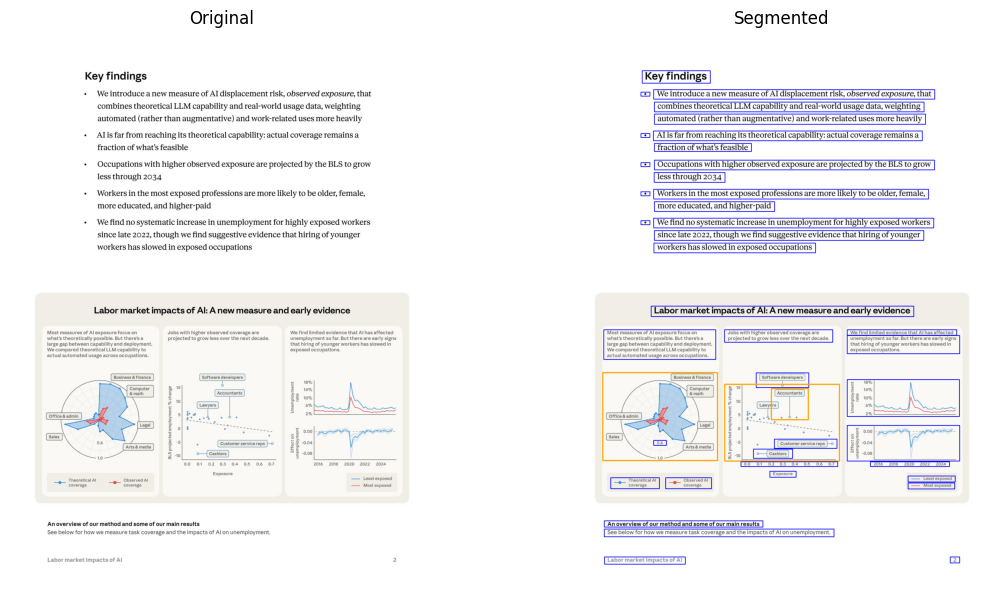

In [23]:
# demo file to test the function on
demo_file = "Anthropic_Report_pg2.jpg"

# run the segmentation function
segmented_result = image_segmentation(demo_file)

# load the original image for comparison
original = cv2.imread(demo_file)

# show them side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# original on the left convert from bgr to rgb so colors look right
ax[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[0].axis('off')

# segmented image on the right convert from bgr to rgb again
ax[1].imshow(cv2.cvtColor(segmented_result, cv2.COLOR_BGR2RGB))
ax[1].set_title("Segmented")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Sub Heading 1

In [ ]:
# code here...

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code